# Metropolis-Hastings algorithm

### Introduction

Metropolis-Hastings is a Markov chain Monte Carlo method for sampling from a target distribution when direct sampling is hard. The target can be known only up to a normalizing constant:

$$
\pi(x)=\frac{\tilde\pi(x)}{Z}.
$$

The strength of this algorithm is that we do not need to calculate the density's normalization constant, which is often difficult in practice.

The algorithm builds a Markov chain whose stationary distribution is $\pi(x)$. After burn-in, the visited states are treated as dependent samples from the target distribution.

There are some variants within the Metropolis-Hastings algorithm, which has specific assumptions and has its own name:

| Name | Proposal | Acceptance correction |
|---|---|---|
| Metropolis-Hastings (most general) | Any proposal $q(x'\mid x)$ | Uses the target ratio and the proposal ratio |
| Metropolis algorithm | Symmetric proposal, $q(x'\mid x)=q(x\mid x')$ | Proposal ratio cancels |
| Random-walk Metropolis | Add symmetric noise, $x'=x+\epsilon$ | A common Metropolis special case |


### Acceptance ratio

At the current state $x$, propose a candidate $x'$ from any proposal distribution $q(x'\mid x)$. The Metropolis-Hastings acceptance probability is

$$
\alpha(x,x')=\min\left(1,
\frac{\pi(x')q(x\mid x')}{\pi(x)q(x'\mid x)}\right).
$$

Because $\pi(x)=\tilde\pi(x)/Z$, the unknown normalizing constant cancels:

$$
\frac{\pi(x')}{\pi(x)}
=\frac{\tilde\pi(x')/Z}{\tilde\pi(x)/Z}
=\frac{\tilde\pi(x')}{\tilde\pi(x)}.
$$

In this notebook we use one common special case: a Gaussian random-walk proposal. It is symmetric, so $q(x'\mid x)=q(x\mid x')$ and the proposal terms also cancel:

$$
\alpha(x,x')=\min\left(1,\frac{\tilde\pi(x')}{\tilde\pi(x)}\right).
$$

### Log-space implementation

In code we usually avoid computing the ratio itself. If $U\sim\mathrm{Uniform}(0,1)$, the proposal is accepted when

$$
U < \frac{\tilde\pi(x')}{\tilde\pi(x)}.
$$

Taking logs gives the equivalent test

$$
\log U < \log\tilde\pi(x')-\log\tilde\pi(x).
$$

This is more stable numerically, and it is the same reason the graph-ensemble sampler compares `math.log(rng.random())` with a change in log weight.

In [ ]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

project_root = Path.home() / "Developer" / "documentation" / "scripts"
sys.path.append(str(project_root))
from utils import get_cbfp_colors, show_fig_svg, show_animation_video_base64

%config InlineBackend.figure_format = 'retina'
plt.rcParams['text.usetex'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = 'Helvetica'
plt.rcParams['svg.fonttype'] = 'path'

rng = np.random.default_rng(42)

colors_cbfp = get_cbfp_colors(2)
COL_SAMPLE = colors_cbfp[5]
COL_TARGET = colors_cbfp[3]
COL_PROPOSAL = colors_cbfp[1]
COL_REJECT = '#5d5d5d'
COL_TEXT = '#222222'
COL_GRID = '#d9d9d9'


def style_axis(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(COL_GRID)
    ax.spines['bottom'].set_color(COL_GRID)
    ax.tick_params(colors=COL_TEXT, labelsize=9)
    ax.grid(True, axis='y', color=COL_GRID, linewidth=0.8, alpha=0.7)


### Target distribution

Let's use a bimodal distribution as a target in this notebook. This is a mixture of two normal densities,

$$
\pi(x)=0.35\,\mathcal{N}(x\mid -2.0,0.55^2)
      +0.65\,\mathcal{N}(x\mid 1.3,0.9^2).
$$

Equivalently,

$$
\pi(x)=0.35\frac{1}{0.55\sqrt{2\pi}}
\exp\left[-\frac{1}{2}\left(\frac{x+2.0}{0.55}\right)^2\right]
+0.65\frac{1}{0.9\sqrt{2\pi}}
\exp\left[-\frac{1}{2}\left(\frac{x-1.3}{0.9}\right)^2\right].
$$

For this example the density is normalized, but the sampler only needs a log density up to an additive constant.

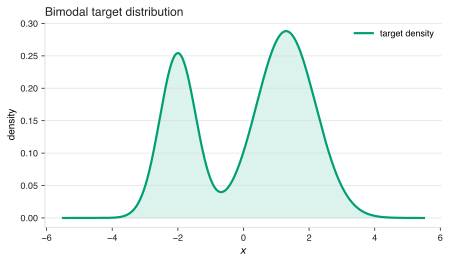

In [ ]:
def normal_pdf(x, mean, sd):
    return np.exp(-0.5 * ((x - mean) / sd) ** 2) / (sd * np.sqrt(2 * np.pi))


def target_pdf(x):
    return 0.35 * normal_pdf(x, -2.0, 0.55) + 0.65 * normal_pdf(x, 1.3, 0.9)


def log_target_unnormalized(x):
    """Log unnormalized density; the missing normalizing constant is irrelevant."""
    a = np.log(0.35) - 0.5 * ((x + 2.0) / 0.55) ** 2 - np.log(0.55)
    b = np.log(0.65) - 0.5 * ((x - 1.3) / 0.9) ** 2 - np.log(0.9)
    m = np.maximum(a, b)
    return m + np.log(np.exp(a - m) + np.exp(b - m))


x_grid = np.linspace(-5.5, 5.5, 600)
fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(x_grid, target_pdf(x_grid), color=COL_TARGET, linewidth=2.2, label='target density')
ax.fill_between(x_grid, target_pdf(x_grid), color=COL_TARGET, alpha=0.14)
ax.set_title('Target distribution', loc='left', fontsize=12, color=COL_TEXT)
ax.set_xlabel('$x$', fontsize=10)
ax.set_ylabel('density', fontsize=10)
style_axis(ax)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout(pad=1.2)
plt.close()
show_fig_svg(fig)


### Random-walk Metropolis sampler

The implementation below is the random-walk Metropolis, which is a special case of Metropolis-Hastings. The proposal is

$$
x'=x+\epsilon,
\qquad
\epsilon\sim\mathcal{N}(0,\sigma^2).
$$

This proposal is symmetric, so the acceptance decision only needs the log target difference. For asymmetric proposals, the log proposal ratio must also be included.

In [ ]:
def metropolis_hastings(log_target, x0, proposal_sd, n_steps, rng):
    """Run a one-dimensional random-walk Metropolis sampler.

    Parameters
    ----------
    log_target : callable
        Function returning the log target density up to an additive constant.
        The normalizing constant is not needed because the sampler uses
        log-density differences.
    x0 : float
        Initial state of the Markov chain.
    proposal_sd : float
        Standard deviation of the Gaussian random-walk proposal.
    n_steps : int
        Number of MCMC iterations to run.
    rng : numpy.random.Generator
        Random generator used for reproducible proposals and accept/reject
        draws.

    Returns
    -------
    samples : numpy.ndarray
        Array of chain states after each iteration.
    accepted : numpy.ndarray
        Boolean array indicating whether each proposal was accepted.
    """
    # Allocate storage for the chain and acceptance indicators.
    samples = np.empty(n_steps)
    accepted = np.zeros(n_steps, dtype=bool)

    # Initialize the chain and cache the current log target value.
    x = float(x0)
    log_px = float(log_target(x))

    for t in range(n_steps):
        # Propose a local move from a symmetric Gaussian random walk.
        x_proposed = x + rng.normal(0, proposal_sd)
        log_p_proposed = float(log_target(x_proposed))

        # Symmetry makes the proposal ratio cancel, leaving a log target ratio.
        log_acceptance_ratio = log_p_proposed - log_px

        # Accept if log(U) is below the log acceptance ratio; otherwise stay put.
        if np.log(rng.random()) < log_acceptance_ratio:
            x = x_proposed
            log_px = log_p_proposed
            accepted[t] = True

        # Record the current state after the accept/reject decision.
        samples[t] = x

    return samples, accepted


In [6]:
from matplotlib import animation

anim_rng = np.random.default_rng(123)
anim_steps = 90
anim_x = -4.8
anim_log_px = float(log_target_unnormalized(anim_x))
anim_records = []

for _ in range(anim_steps):
    x_current = anim_x
    log_current = anim_log_px
    x_proposed = x_current + anim_rng.normal(0, 0.9)
    log_proposed = float(log_target_unnormalized(x_proposed))
    log_acceptance_ratio = log_proposed - log_current
    log_u = np.log(anim_rng.random())
    accepted_step = log_u < log_acceptance_ratio

    if accepted_step:
        anim_x = x_proposed
        anim_log_px = log_proposed

    anim_records.append((x_current, x_proposed, anim_x, accepted_step, log_acceptance_ratio, log_u))

fig, ax = plt.subplots(figsize=(8.6, 5.0))
ax.plot(x_grid, target_pdf(x_grid), color=COL_TARGET, linewidth=2.2, label='target density')
ax.fill_between(x_grid, target_pdf(x_grid), color=COL_TARGET, alpha=0.12)

current_marker = ax.scatter([], [], s=120, color=COL_SAMPLE, zorder=5, label='current')
proposal_marker = ax.scatter([], [], s=120, facecolor='white', edgecolor=COL_PROPOSAL, linewidth=2.4, zorder=6, label='proposal')
accepted_points = ax.scatter([], [], marker='|', s=120, color=COL_SAMPLE, alpha=0.85, zorder=4)
rejected_points = ax.scatter([], [], marker='x', s=48, color=COL_REJECT, alpha=0.8, zorder=4)
(move_line,) = ax.plot([], [], color=COL_REJECT, linewidth=1.2, linestyle=':', zorder=3)
(status_text) = ax.text(0.02, 0.93, '', transform=ax.transAxes, color=COL_TEXT, fontsize=11, va='top')

ax.axhline(-0.015, color=COL_GRID, linewidth=1.0)
ax.set_xlim(-5.5, 5.5)
ax.set_ylim(-0.045, 0.34)
ax.set_xlabel('$x$', fontsize=10)
ax.set_ylabel('density', fontsize=10)
ax.set_title('Metropolis-Hastings proposal steps', loc='left', fontsize=13, color=COL_TEXT)
ax.legend(loc='upper right', frameon=False, fontsize=9)
style_axis(ax)

accepted_x = []
rejected_x = []


def init_animation():
    accepted_x.clear()
    rejected_x.clear()
    current_marker.set_offsets(np.empty((0, 2)))
    proposal_marker.set_offsets(np.empty((0, 2)))
    accepted_points.set_offsets(np.empty((0, 2)))
    rejected_points.set_offsets(np.empty((0, 2)))
    move_line.set_data([], [])
    status_text.set_text('')
    return current_marker, proposal_marker, accepted_points, rejected_points, move_line, status_text


def update_animation(frame):
    x_current, x_proposed, x_next, accepted_step, log_ratio, log_u = anim_records[frame]
    y_current = target_pdf(x_current)
    y_proposed = target_pdf(x_proposed)

    current_marker.set_offsets([[x_current, y_current]])
    proposal_marker.set_offsets([[x_proposed, y_proposed]])
    move_line.set_data([x_current, x_proposed], [y_current, y_proposed])

    if accepted_step:
        accepted_x.append(x_next)
    else:
        rejected_x.append(x_proposed)

    if accepted_x:
        accepted_points.set_offsets(np.column_stack([accepted_x, np.full(len(accepted_x), -0.015)]))
    else:
        accepted_points.set_offsets(np.empty((0, 2)))

    if rejected_x:
        rejected_points.set_offsets(np.column_stack([rejected_x, np.full(len(rejected_x), -0.032)]))
    else:
        rejected_points.set_offsets(np.empty((0, 2)))

    decision = 'accept' if accepted_step else 'reject'
    status_text.set_text(
        f"step {frame + 1}: {decision}\n"
        f"log U = {log_u:.2f},  log ratio = {log_ratio:.2f}"
    )
    return current_marker, proposal_marker, accepted_points, rejected_points, move_line, status_text


mh_anim = animation.FuncAnimation(
    fig,
    update_animation,
    init_func=init_animation,
    frames=anim_steps,
    interval=180,
    blit=True,
    cache_frame_data=False,
)

plt.close()


The animation shows the local Metropolis step. The chain starts at the current state $x$, proposes $x'$, then either moves to $x'$ or stays at $x$ based on the log acceptance test. Rejected proposals are shown separately because the chain remains at the previous state.

In [7]:
show_animation_video_base64(mh_anim, fps=5)

You can see the Metropolis-Hastings step visually in 3D here:

<LinkCard
  href="https://mcmc-visualization.vercel.app/"
  title="MCMC Visualization"
  favicon={false}
/>

Run the chain from a low-density starting point and discard an initial burn-in period.

In [3]:
samples, accepted = metropolis_hastings(
    log_target=log_target_unnormalized,
    x0=-5.5,
    proposal_sd=0.85,
    n_steps=30_000,
    rng=rng,
)

burn_in = 3_000
kept = samples[burn_in:]
acceptance_rate = accepted.mean()

print(f"Steps: {len(samples):,}")
print(f"Burn-in discarded: {burn_in:,}")
print(f"Proposal standard deviation: 0.85")
print(f"Acceptance rate: {acceptance_rate:.1%}")
print(f"Posterior/sample mean after burn-in: {kept.mean():.3f}")
print(f"Posterior/sample standard deviation after burn-in: {kept.std(ddof=1):.3f}")


Steps: 30,000
Burn-in discarded: 3,000
Proposal standard deviation: 0.85
Acceptance rate: 70.8%
Posterior/sample mean after burn-in: 0.091
Posterior/sample standard deviation after burn-in: 1.785


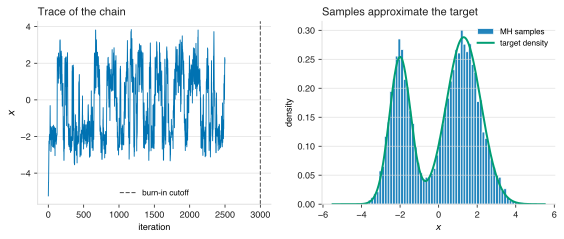

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8, 3.5))
for ax in axes:
    style_axis(ax)

axes[0].plot(samples[:2500], color=COL_SAMPLE, linewidth=0.9)
axes[0].axvline(burn_in, color=COL_REJECT, linewidth=1.1, linestyle='--', label='burn-in cutoff')
axes[0].set_title('Trace of the chain', loc='left', fontsize=11, color=COL_TEXT)
axes[0].set_xlabel('iteration', fontsize=9)
axes[0].set_ylabel('$x$', fontsize=10)
axes[0].legend(frameon=False, fontsize=8)

axes[1].hist(kept, bins=65, density=True, color=COL_SAMPLE, alpha=0.86, edgecolor='white', linewidth=0.7, label='MH samples')
axes[1].plot(x_grid, target_pdf(x_grid), color=COL_TARGET, linewidth=2.0, label='target density')
axes[1].set_title('Samples approximate the target', loc='left', fontsize=11, color=COL_TEXT)
axes[1].set_xlabel('$x$', fontsize=9)
axes[1].set_ylabel('density', fontsize=9)
axes[1].legend(frameon=False, fontsize=8)

fig.tight_layout(pad=1.3)
plt.close()
show_fig_svg(fig)


The histogram is not produced by independent draws. Consecutive points are correlated because each point is generated by modifying the previous state. The Markov chain is useful because its long-run distribution is the target distribution.

### Proposal scale and mixing

The proposal standard deviation controls a tradeoff. If proposals are too small, most proposals are accepted but the chain moves slowly. If proposals are too large, many proposals jump into low-density regions and get rejected.

In [5]:
def autocorrelation(x, max_lag):
    centered = x - np.mean(x)
    denom = np.dot(centered, centered)
    values = [1.0]
    for lag in range(1, max_lag + 1):
        values.append(float(np.dot(centered[:-lag], centered[lag:]) / denom))
    return np.array(values)


rng_small = np.random.default_rng(10)
small_samples, small_accept = metropolis_hastings(
    log_target_unnormalized, x0=-5.5, proposal_sd=0.12, n_steps=12_000, rng=rng_small
)

rng_large = np.random.default_rng(10)
large_samples, large_accept = metropolis_hastings(
    log_target_unnormalized, x0=-5.5, proposal_sd=4.5, n_steps=12_000, rng=rng_large
)

small_kept = small_samples[2_000:]
large_kept = large_samples[2_000:]

print(f"Small proposal sd=0.12: acceptance={small_accept.mean():.1%}, sample sd={small_kept.std(ddof=1):.3f}")
print(f"Large proposal sd=4.50: acceptance={large_accept.mean():.1%}, sample sd={large_kept.std(ddof=1):.3f}")


Small proposal sd=0.12: acceptance=94.7%, sample sd=1.748
Large proposal sd=4.50: acceptance=34.2%, sample sd=1.765


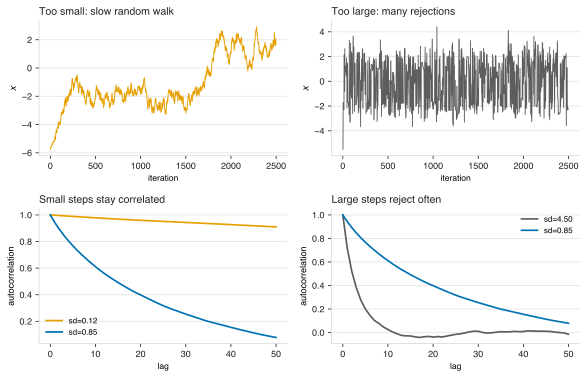

In [6]:
acf_main = autocorrelation(kept, 50)
acf_small = autocorrelation(small_kept, 50)
acf_large = autocorrelation(large_kept, 50)
lags = np.arange(len(acf_main))

fig, axes = plt.subplots(2, 2, figsize=(8.3, 5.4))
for ax in axes.flat:
    style_axis(ax)

axes[0, 0].plot(small_samples[:2500], color=COL_PROPOSAL, linewidth=0.9)
axes[0, 0].set_title('Too small: slow random walk', loc='left', fontsize=10.5, color=COL_TEXT)
axes[0, 0].set_xlabel('iteration', fontsize=8.5)
axes[0, 0].set_ylabel('$x$', fontsize=9)

axes[0, 1].plot(large_samples[:2500], color=COL_REJECT, linewidth=0.9)
axes[0, 1].set_title('Too large: many rejections', loc='left', fontsize=10.5, color=COL_TEXT)
axes[0, 1].set_xlabel('iteration', fontsize=8.5)
axes[0, 1].set_ylabel('$x$', fontsize=9)

axes[1, 0].plot(lags, acf_small, color=COL_PROPOSAL, linewidth=1.7, label='sd=0.12')
axes[1, 0].plot(lags, acf_main, color=COL_SAMPLE, linewidth=1.7, label='sd=0.85')
axes[1, 0].set_title('Small steps stay correlated', loc='left', fontsize=10.5, color=COL_TEXT)
axes[1, 0].set_xlabel('lag', fontsize=8.5)
axes[1, 0].set_ylabel('autocorrelation', fontsize=9)
axes[1, 0].legend(frameon=False, fontsize=8)

axes[1, 1].plot(lags, acf_large, color=COL_REJECT, linewidth=1.7, label='sd=4.50')
axes[1, 1].plot(lags, acf_main, color=COL_SAMPLE, linewidth=1.7, label='sd=0.85')
axes[1, 1].set_title('Large steps reject often', loc='left', fontsize=10.5, color=COL_TEXT)
axes[1, 1].set_xlabel('lag', fontsize=8.5)
axes[1, 1].set_ylabel('autocorrelation', fontsize=9)
axes[1, 1].legend(frameon=False, fontsize=8)

fig.tight_layout(pad=1.2)
plt.close()
show_fig_svg(fig)


### Summary

Metropolis-Hastings is useful when the target density is available up to proportionality:

$$
\pi(x)\propto\tilde\pi(x).
$$

The algorithm does not require direct samples from $\pi(x)$ and does not require the normalizing constant $Z$. It only needs ratios of target density values, often implemented as differences in log density.

For symmetric random-walk proposals, the acceptance test is

$$
\log U < \log\tilde\pi(x')-\log\tilde\pi(x).
$$

For non-symmetric proposals, the proposal-density ratio must be included as well.